In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
import xarray as xr 
import cmocean
import matplotlib.colors as colors

from feature_retreiver import FeatureRetreiver

from utility import (
    compute_u_star, calculate_B
)

In [14]:
ds = xr.open_dataset("/gpfs/f5/gfdl_o/scratch/Marta.Mrozowska/hurricane_LES/GOTM/gotm-cases/ows_papa/ows_papa_keps_era5_sane23.nc").isel(lat=0, lon=0)

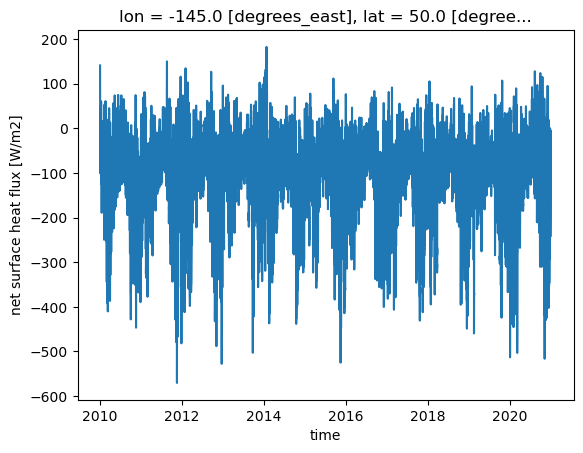

In [16]:
ds.heat.plot()

In [46]:
ds = xr.open_dataset('/gpfs/f5/gfdl_o/scratch/Marta.Mrozowska/hurricane_LES/make_smc_training_set/ePBL_paper_GLS_training_dataset/case_6/output.nc').isel(lat=0, lon=0)

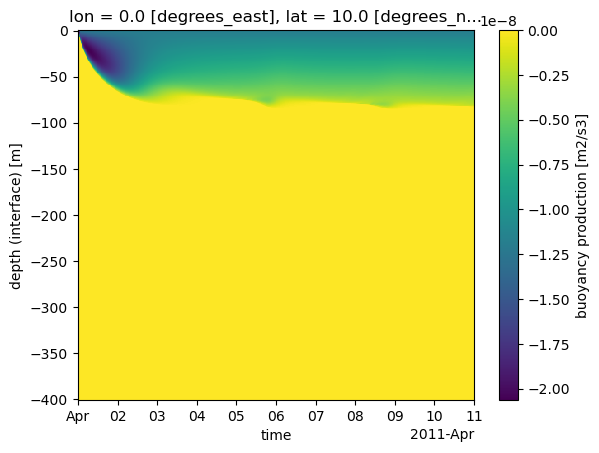

In [47]:
ds.G.T.plot()

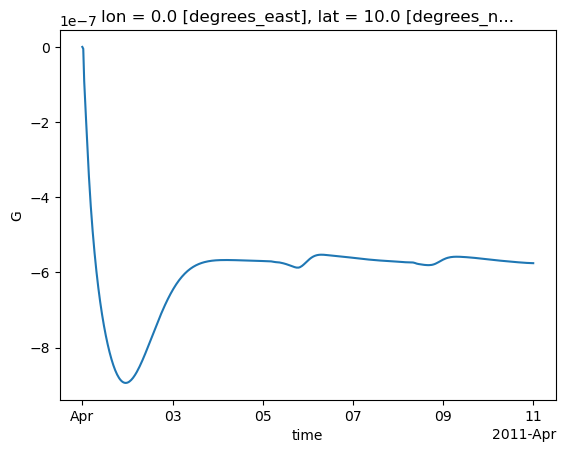

In [48]:
ds.G.where(ds.G < 0).sum(dim="zi").plot()

In [11]:
ds = ds.sel(time=slice(np.datetime64('2015'), np.datetime64('2016')))

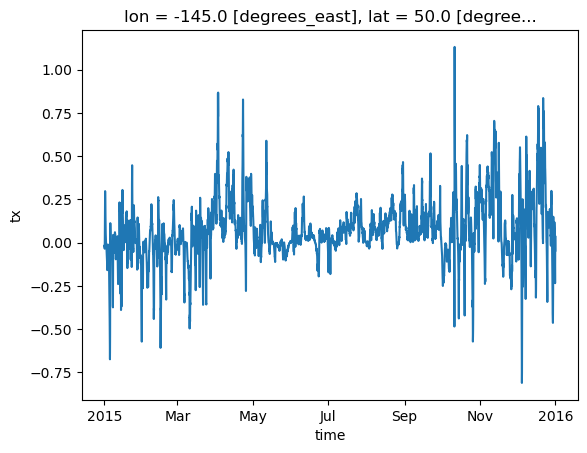

In [5]:
(ds.tx*1027).plot()

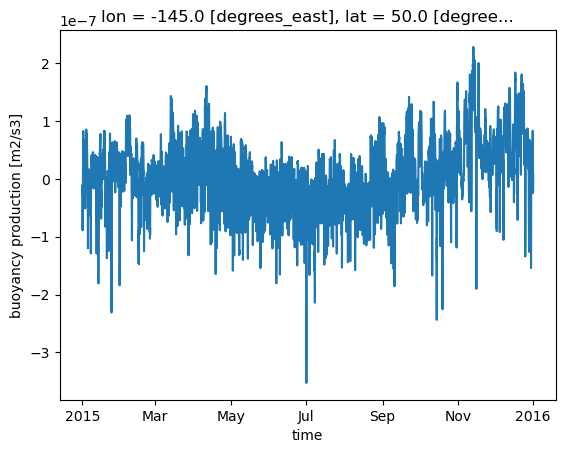

In [179]:
ds.G[:,-2].plot()

In [6]:
def calculate_storage_term(output: xr.Dataset) -> np.ndarray:
    return np.pad((output['tke'].diff(dim="time") / 3600).sum(dim="zi").values, pad_width=(0,1), mode="edge")

In [7]:
def compute_u_star(output: xr.Dataset) -> np.ndarray:
    u_star = (np.sqrt((output.tx.values*1000) ** 2 + (output.ty.values*1000) ** 2) / 1027) ** 0.5
    # u_star = np.where(u_star < 1e-2, 1e-2, u_star)
    return u_star

In [8]:
def calculate_m_star(output: xr.Dataset) -> np.ndarray:
    wb = -output.G.values
    wb[wb < 0] = 0
    M = np.sum(wb, axis=1)
    m_star = M / (compute_u_star(output)) ** 3
    return M, m_star

In [43]:
def compute_bl_rh18(
        output: xr.Dataset,
        variable: str = "nuh"
) -> np.ndarray:
    bl_mask = np.where(output[variable][:,-120:-1].values > 1e-6, -output['zi'][:,-120:-1].values, np.nan)
    bl = np.nanmax(bl_mask, axis=1)
    bl = np.where(np.isnan(bl), 1.0, bl)
    return bl

In [42]:
def extract_var_at_bl(
        output: xr.Dataset,
        variable: str
):
    t, z = output[variable][:,-120:].shape
    z_grid = np.arange(z)[::-1]
    z_mask = np.where(output['nuh'].values[:,-120:] > 1e-6, z_grid, np.nan)
    z_indices = np.nanmax(z_mask, axis=1)
    z_indices = np.where(np.isnan(z_indices), 1, z_indices).astype(int)
    
    return output[variable].values[np.arange(t),-z_indices+2]

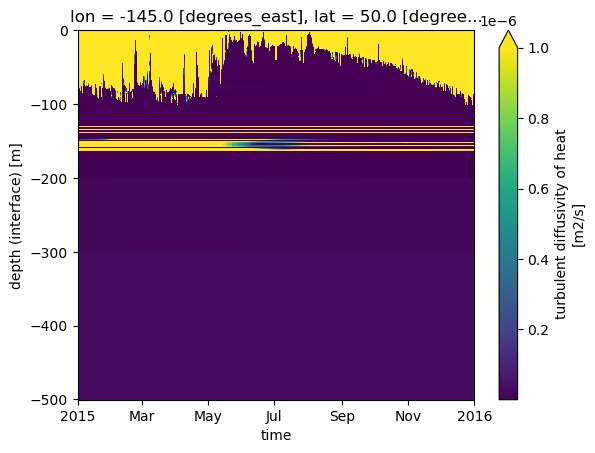

In [17]:
ds['nuh'].T.plot(vmax=1e-6)

In [18]:
def calculate_rolling_average(
        data: np.ndarray,
        window_size: int
) -> np.ndarray:
    return np.convolve(np.pad(data, pad_width=int(window_size/2), mode="reflect"), np.ones(window_size)/window_size, mode='valid')[:-1]

In [19]:
def calculate_f(latitude: float):
    omega = 2 * np.pi / 24 / 60 / 60
    return 2 * omega * np.sin(latitude * np.pi / 180)

In [20]:
def calculate_reduced_M(
        m_star: np.ndarray,
        u_star: np.ndarray,
        bl: np.ndarray,
        buoyancy_flux: np.ndarray
):
    x = (2 * m_star * u_star**3) / bl
    return m_star * u_star**3 * ( x / (-buoyancy_flux + x))

In [21]:
def calculate_phi(
        m_star: np.ndarray,
        u_star: np.ndarray,
        bl: np.ndarray,
        buoyancy_flux: np.ndarray,
        c_phi: float = 0.67
):
    x = (2 * m_star * u_star**3) / bl
    return x / (c_phi * -buoyancy_flux * bl + x)

In [22]:
time = ds.time.values

In [64]:
surface_salinity = ds.sss.values
evaporation = ds.evap.values
precipitation = ds.precip.values

In [66]:
rho0 = 1027
g = 9.81
alpha = 2e-4
beta = 7.5e-4
cp = 4e3

M, m_star = calculate_m_star(ds)
heat_flux = ds.heat.values
u_star = compute_u_star(ds)
bl = compute_bl_rh18(ds)
buoyancy_flux = g * (alpha * heat_flux / (rho0 * cp) - beta * (evaporation - precipitation) * surface_salinity)
reduced_M = calculate_reduced_M(m_star, u_star, bl, buoyancy_flux)
window_size = 24 * 10

corrected_M = np.where(buoyancy_flux < 0, reduced_M, M)
corrected_m_star = corrected_M / u_star**3


/tmp/ipykernel_1098966/3503593106.py:6: RuntimeWarning: All-NaN slice encountered
  bl = np.nanmax(bl_mask, axis=1)


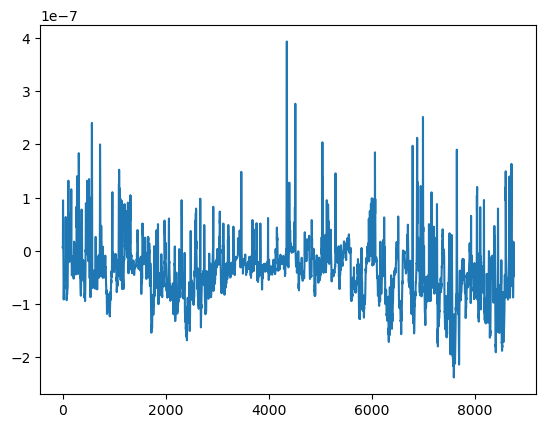

In [67]:
plt.plot(buoyancy_flux)

In [46]:
reduced_m_star = np.where(buoyancy_flux < 0, calculate_phi(m_star, u_star, bl, buoyancy_flux)*m_star, m_star)

(0.0, 5.0)

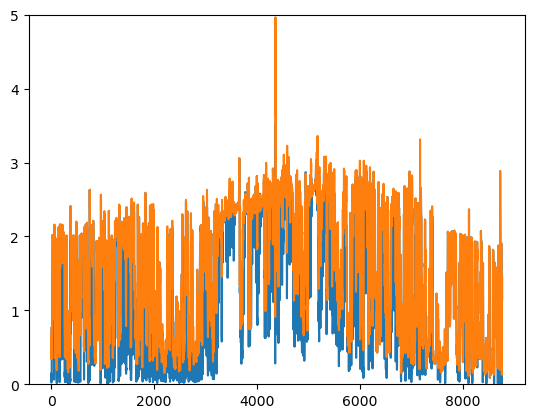

In [236]:
plt.plot(reduced_m_star)
plt.plot(corrected_m_star)
plt.ylim(0,5)

In [68]:
arrays = [heat_flux, u_star, bl, buoyancy_flux, heat_flux, M]
names = ["heat_flux", "u_star", "bl", "buoyancy_flux", "heat_flux", "M"]

[np.save(f"{name}_ows_papa_2015_sane23.npy", array) for array, name in zip(arrays, names)]

[None, None, None, None, None, None]

In [65]:
arrays = [evaporation, precipitation, surface_salinity]
names = ["evaporation", "precipitation", "surface_salinity"]

[np.save(f"{name}_ows_papa_2015_sane23.npy", array) for array, name in zip(arrays, names)]

[None, None, None]

In [48]:
u, v = ds.u.isel(z=-1).values, ds.v.isel(z=-1).values
np.save("u_surf_ows_papa_2015_sane23.npy", u)
np.save("v_surf_ows_papa_2015_sane23.npy", v)

In [49]:
tx, ty = ds.tx.values * 1000, ds.ty.values * 1000

In [50]:
np.save("tx_surf_ows_papa_2015_sane23.npy", tx)
np.save("ty_surf_ows_papa_2015_sane23.npy", ty)

In [51]:
udottau = ds.tx.values * 1000 * ds.u.isel(z=-1).values + ds.ty.values * 1000 * ds.v.isel(z=-1).values

In [13]:
np.save("udottau_ows_papa_2015.npy", udottau)

In [52]:
u_bl = extract_var_at_bl(output=ds, variable="u")
v_bl = extract_var_at_bl(output=ds, variable="v")
NN_bl = extract_var_at_bl(output=ds, variable="NN")
SS_bl = extract_var_at_bl(output=ds, variable="SS")

In [54]:
arrays = [u_bl, v_bl, NN_bl, SS_bl]
names = ["u_bl", "v_bl", "NN_bl", "SS_bl"]

[np.save(f"{name}_ows_papa_2015_sane23.npy", array) for array, name in zip(arrays, names)]

[None, None, None, None]

In [205]:
hf_threshold = 10

m_star_no_hf = m_star[np.abs(heat_flux) < hf_threshold]
u_star_no_hf = u_star[np.abs(heat_flux) < hf_threshold]
heat_flux_no_hf = heat_flux[np.abs(heat_flux) < hf_threshold]
bl_no_hf = bl[np.abs(heat_flux) < hf_threshold]
M_no_hf = M[np.abs(heat_flux) < hf_threshold]

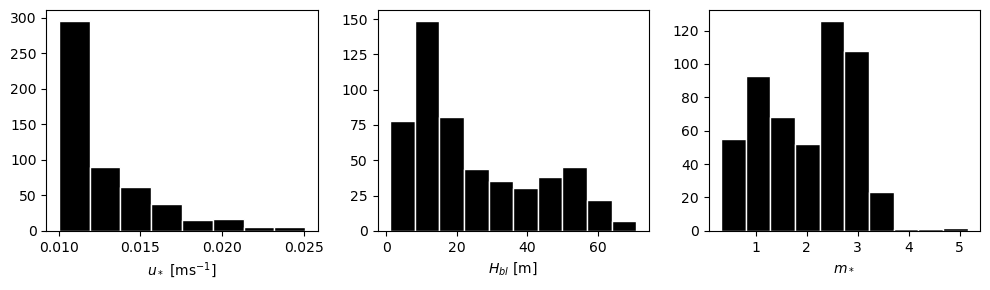

In [195]:
fig, ax = plt.subplots(1,3, figsize=(10,3))

ax[0].hist(u_star_no_hf, 8, color="black", edgecolor="white")
ax[0].set_xlabel("$u_*$ [ms$^{-1}$]")
ax[1].hist(bl_no_hf, color="black", edgecolor="white")
ax[1].set_xlabel("$H_{bl}$ [m]")
# ax[2].hist(heat_flux_no_hf, 9, color="black", edgecolor="white")
# ax[2].set_xlabel("Heat flux [W/m$^2$]")
ax[2].hist(m_star_no_hf, color="black", edgecolor="white")
ax[2].set_xlabel("$m_*$")

fig.tight_layout()

# plt.savefig("ows_papa_input_distributions_no_hf.png", dpi=300)

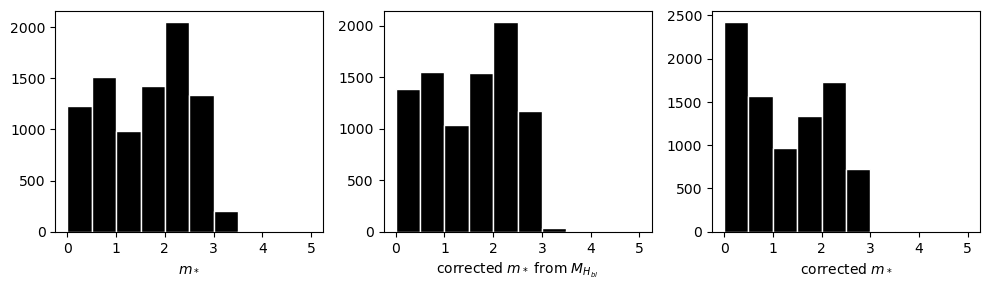

In [241]:
fig, ax = plt.subplots(1,3, figsize=(10,3))

ax[0].hist(m_star, np.arange(0,5.5,0.5), color="black", edgecolor="white")
ax[0].set_xlabel("$m_*$")
ax[1].hist(corrected_m_star, np.arange(0,5.5,0.5), color="black", edgecolor="white")
ax[1].set_xlabel("corrected $m_*$ from $M_{H_{bl}}$")
ax[2].hist(reduced_m_star, np.arange(0,5.5,0.5), color="black", edgecolor="white")
ax[2].set_xlabel("corrected $m_*$")
# ax[2].hist(heat_flux_no_hf, 9, color="black", edgecolor="white")
# ax[2].set_xlabel("Heat flux [W/m$^2$]")
# ax[2].hist(m_star_no_hf, color="black", edgecolor="white")
# ax[2].set_xlabel("$m_*$")

fig.tight_layout()

plt.savefig("m_star_vs_m_star_hf_corrected_two_ways.png", dpi=300)

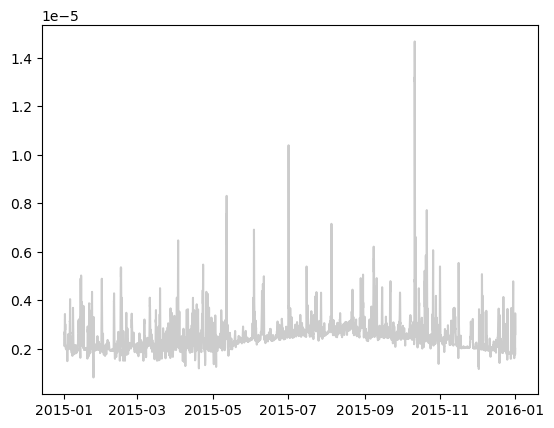

In [196]:
plt.plot(time, np.where(buoyancy_flux < 0, reduced_M, M), color="black", alpha=.2)

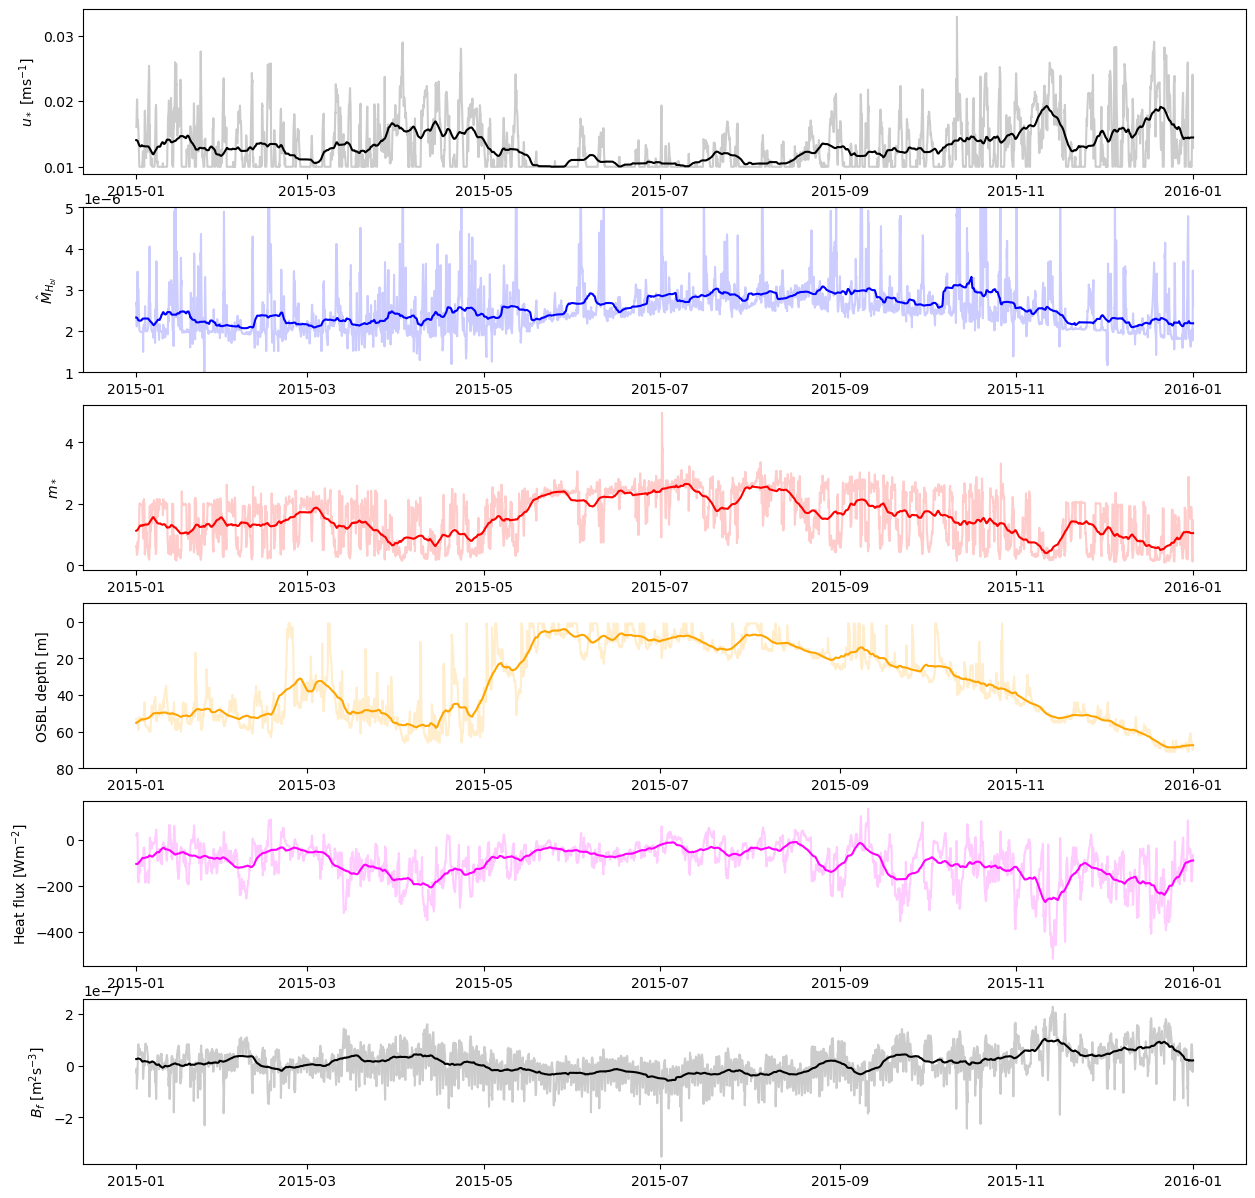

In [29]:
fig, ax = plt.subplots(6,1,figsize=(15,15))
ax[0].plot(time[1:], u_star[1:], color="black", alpha=.2)
ax[0].plot(time[1:], calculate_rolling_average(u_star[1:], window_size), color="black")
ax[0].set_ylabel("$u_*$ [ms$^{-1}$]")
ax[1].plot(time, corrected_M, color="blue", alpha=.2)
ax[1].plot(time, calculate_rolling_average(corrected_M, window_size), color="blue")
ax[1].set_ylabel(r"$\hat{M}_{H_{bl}}$")
ax[1].set_ylim(.1e-5, .5e-5)
ax[2].plot(time, corrected_m_star, color="red", alpha=.2)
ax[2].plot(time, calculate_rolling_average(corrected_m_star, window_size), color="red")
ax[2].set_ylabel("$m_*$")
ax[3].plot(time, bl, color="orange", alpha=.2)
ax[3].plot(time, calculate_rolling_average(bl, window_size), color="orange")
ax[3].set_ylabel("OSBL depth [m]")
ax[3].set_ylim(80,-10)
ax[4].plot(time, heat_flux, color="magenta", alpha=.2)
ax[4].plot(time, calculate_rolling_average(heat_flux, window_size), color="magenta")
ax[4].set_ylabel("Heat flux [Wm$^{-2}$]")
ax[5].plot(time, buoyancy_flux, color="black", alpha=.2)
ax[5].plot(time, calculate_rolling_average(buoyancy_flux, window_size), color="black")
ax[5].set_ylabel("$B_f$ [m$^2$s$^{-3}$]")
# ax[5].plot(time, calculate_storage_term(ds)/compute_buoyancy_mixing_term(ds), color="black", alpha=.2)
# ax[5].plot(time, calculate_rolling_average(calculate_storage_term(ds)/compute_buoyancy_mixing_term(ds), 24), color="black")
# ax[5].set_ylabel("storage/buoyancy mixing")
# ax[5].set_ylim(-1,1)

plt.savefig("OWS_Papa_2015_summary_corrected_with_bf.png", dpi=300)

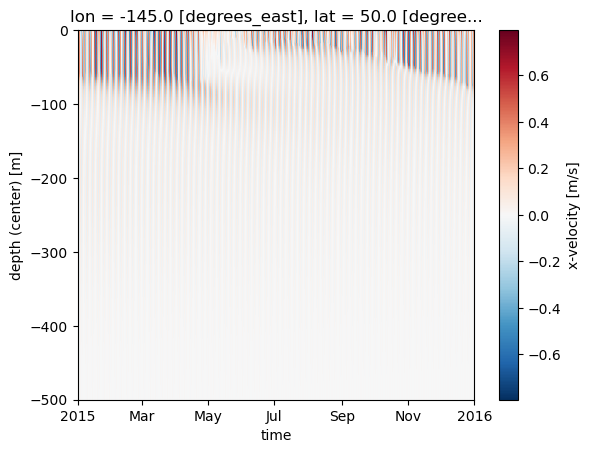

In [27]:
ds.u.T.plot()

Text(0, 0.5, '$B_f$ [m$^2$s$^{-3}$]')

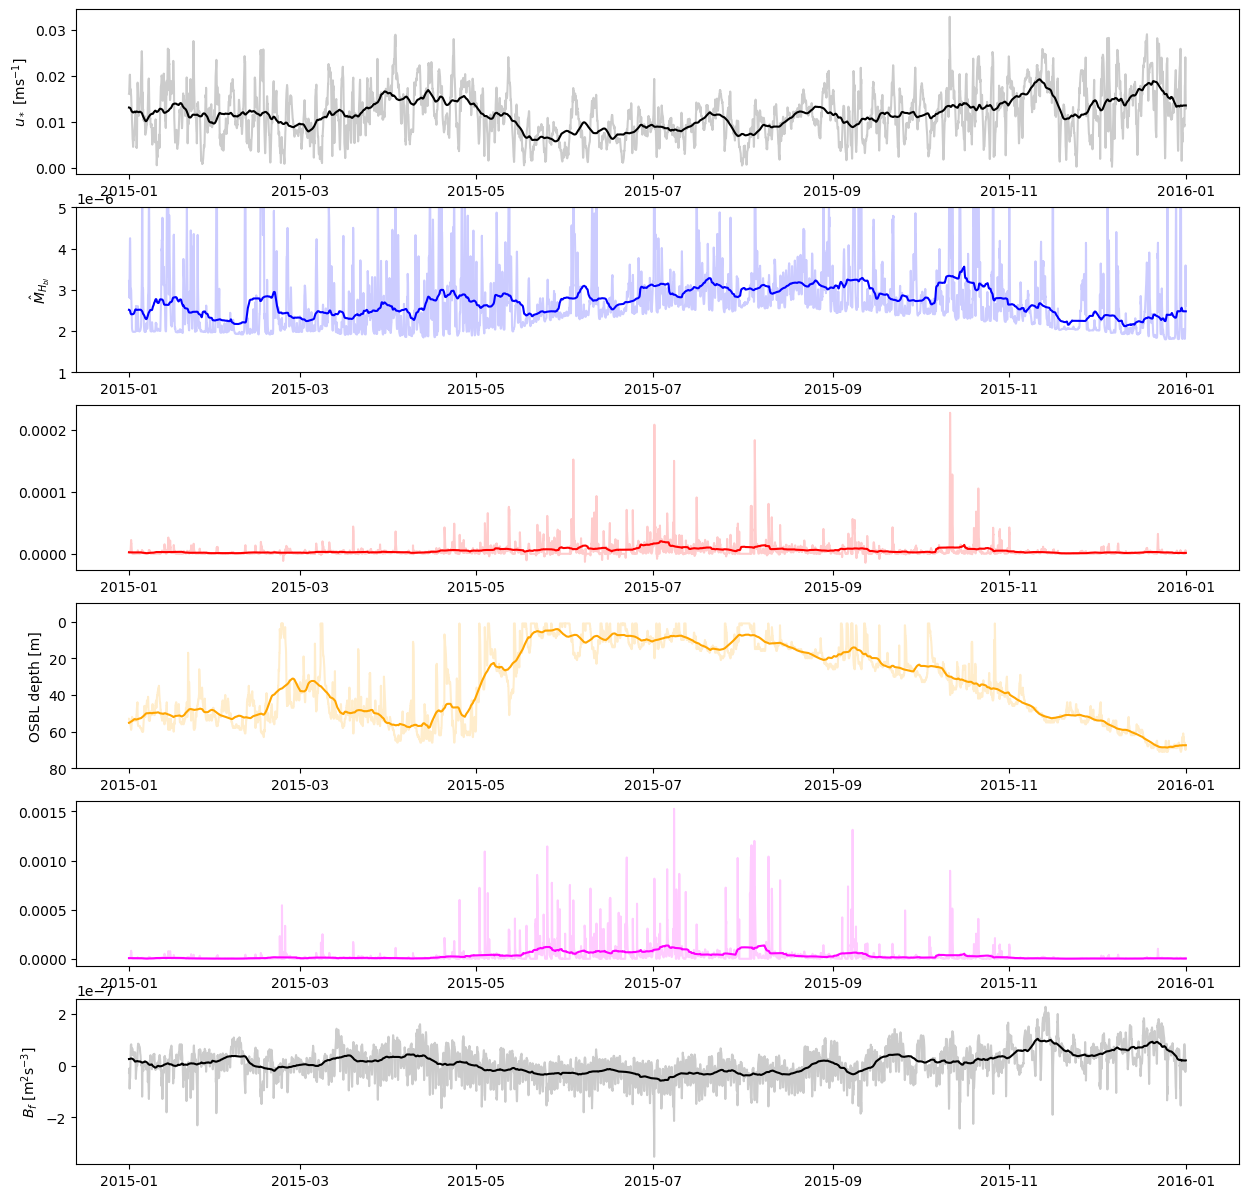

In [67]:
fig, ax = plt.subplots(6,1,figsize=(15,15))
ax[0].plot(time[1:], u_star[1:], color="black", alpha=.2)
ax[0].plot(time[1:], calculate_rolling_average(u_star[1:], window_size), color="black")
ax[0].set_ylabel("$u_*$ [ms$^{-1}$]")
ax[1].plot(time, M, color="blue", alpha=.2)
ax[1].plot(time, calculate_rolling_average(M, window_size), color="blue")
ax[1].set_ylabel(r"$\hat{M}_{H_{bl}}$")
ax[1].set_ylim(.1e-5, .5e-5)
ax[2].plot(time, NN_bl, color="red", alpha=.2)
ax[2].plot(time, calculate_rolling_average(NN_bl, window_size), color="red")
# ax[2].set_ylabel("$u_{bl}$")
ax[3].plot(time, bl, color="orange", alpha=.2)
ax[3].plot(time, calculate_rolling_average(bl, window_size), color="orange")
ax[3].set_ylabel("OSBL depth [m]")
ax[3].set_ylim(80,-10)
ax[4].plot(time, SS_bl, color="magenta", alpha=.2)
ax[4].plot(time, calculate_rolling_average(SS_bl, window_size), color="magenta")
# ax[4].set_ylabel("v_{bl}$]")
ax[5].plot(time, buoyancy_flux, color="black", alpha=.2)
ax[5].plot(time, calculate_rolling_average(buoyancy_flux, window_size), color="black")
ax[5].set_ylabel("$B_f$ [m$^2$s$^{-3}$]")
# ax[5].plot(time, calculate_storage_term(ds)/compute_buoyancy_mixing_term(ds), color="black", alpha=.2)
# ax[5].plot(time, calculate_rolling_average(calculate_storage_term(ds)/compute_buoyancy_mixing_term(ds), 24), color="black")
# ax[5].set_ylabel("storage/buoyancy mixing")
# ax[5].set_ylim(-1,1)

# plt.savefig("OWS_Papa_2015_summary_corrected_with_bf.png", dpi=300)

In [212]:
xs_avgd = calculate_rolling_average(bl, window_size)*calculate_f(50) / (calculate_rolling_average(u_star, window_size) / 1027) ** 0.5
xs = bl*calculate_f(50) / (u_star / 1027) ** 0.5
xs_no_hf = bl_no_hf*calculate_f(50) / (u_star_no_hf / 1027) ** 0.5

In [213]:
def calculate_analytical_m_star_N(x, c_N1, c_N2, c_N3):
    return c_N1 * (1 - (1 + c_N2 * np.exp(-c_N3*x)) ** -1)

In [214]:
def calculate_analytical_m_star_Nb(x, c_Nb1, c_Nb2):
    return c_Nb1 * np.exp(-c_Nb2 * x)

In [215]:
xs_N = np.linspace(0, 1, 1000)
m_star_N = calculate_analytical_m_star_N(xs_N, c_N1=0.275, c_N2 = 8.0, c_N3 = 5.0)
m_star_Nb = calculate_analytical_m_star_Nb(xs_N, c_Nb1=0.5, c_Nb2=3.0)

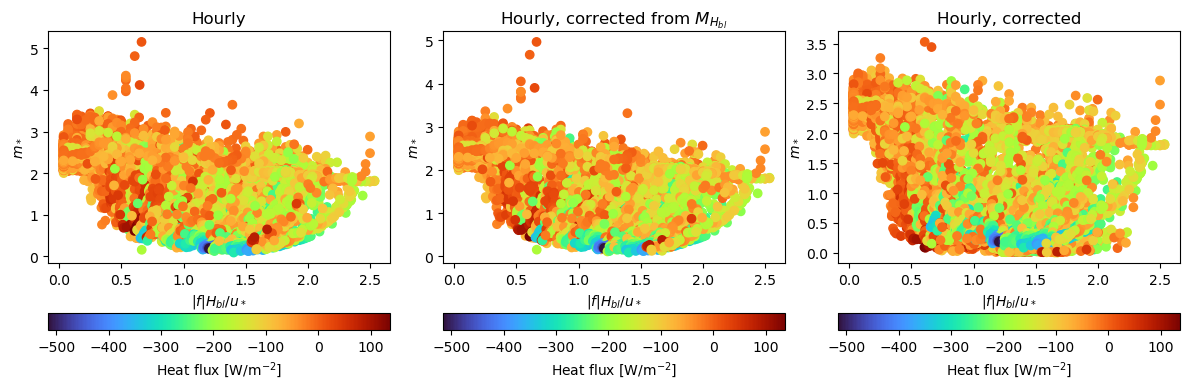

In [245]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4))

c0 = ax[0].scatter(xs, m_star, c=heat_flux, cmap="turbo")
c1 = ax[1].scatter(xs, corrected_m_star, c=heat_flux, cmap="turbo")
c2 = ax[2].scatter(xs, reduced_m_star, c=heat_flux, cmap="turbo")
plt.colorbar(c0, ax=ax[0], orientation="horizontal", label="Heat flux [W/m$^{-2}$]")
plt.colorbar(c1, ax=ax[1], orientation="horizontal", label="Heat flux [W/m$^{-2}$]")
plt.colorbar(c2, ax=ax[2], orientation="horizontal", label="Heat flux [W/m$^{-2}$]")
ax[0].set_title("Hourly")
ax[1].set_title("Hourly, corrected from $M_{H_{bl}}$")
ax[2].set_title("Hourly, corrected")
for a in ax.flatten():
    a.set_xlabel("$|f|H_{bl}/u_*$")
    a.set_ylabel("$m_*$")
    # a.set_yscale("log")
    # a.set_ylim(-0.5, 5.5)

fig.tight_layout()
# plt.plot(xs_N, m_star_N, color="red", linestyle="dashed", alpha=0.2, label="RH18 $m_{*N}$")
# plt.plot(xs_N, m_star_Nb, color="blue", linestyle="dashed", alpha=0.2, label="RH18 $m_{*Nb}$")
plt.savefig("m_star_ows_papa_hf_correction_two_ways.png", dpi=300)

/tmp/ipykernel_79060/3808439837.py:5: UserWarning: Log scale: values of z <= 0 have been masked
  plt.contourf(time, z, nuh, norm=colors.LogNorm())


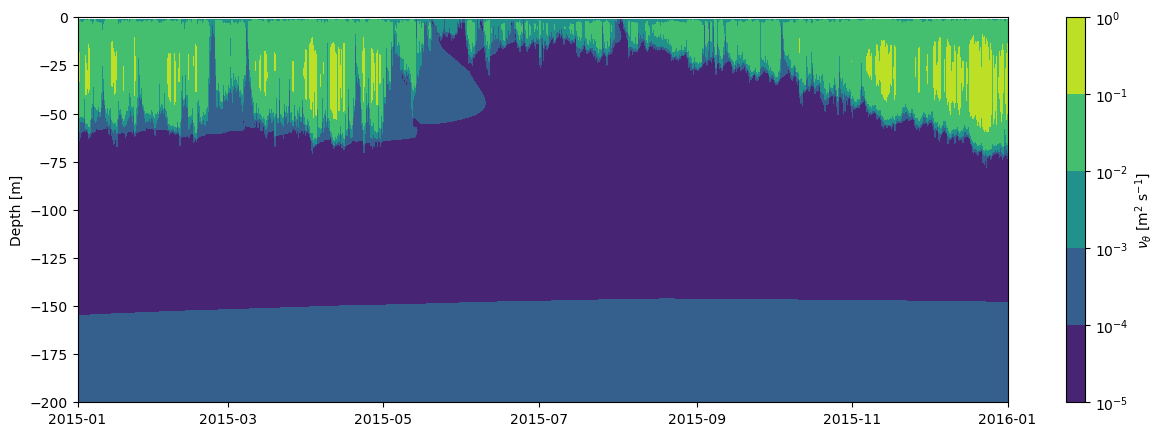

In [27]:
nuh = ds.nuh.T.values
time, z = ds.time.values, ds.zi[0].values

plt.figure(figsize=(15,5))
plt.contourf(time, z, nuh, norm=colors.LogNorm())
plt.ylim(-200,0)
plt.ylabel("Depth [m]")

plt.colorbar(label=r"$\nu_\theta$ [m$^2$ s$^{-1}$]")

plt.savefig("OWS_Papa_2015_nuh.png", dpi=300)

(-6.0, 6.0)

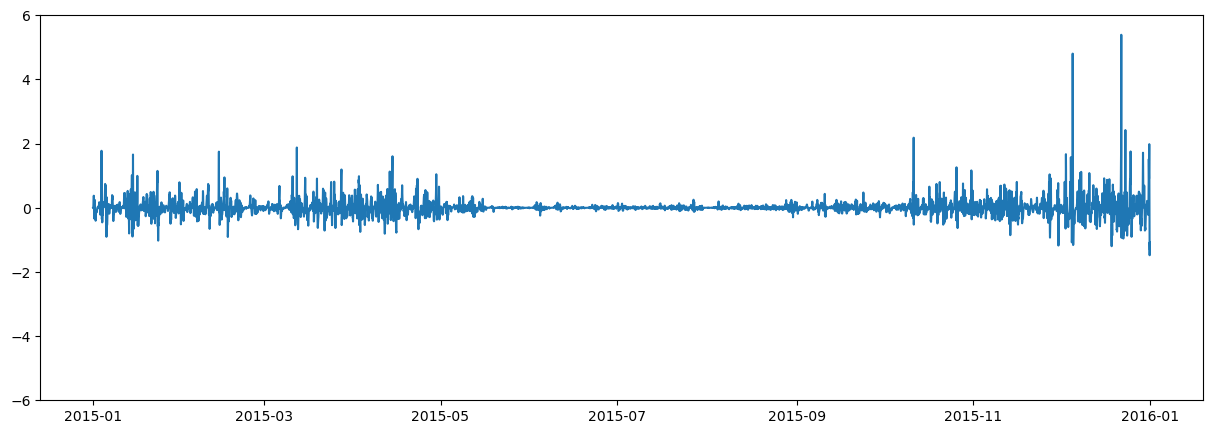

In [14]:
plt.figure(figsize=(15,5))
plt.plot(time, calculate_storage_term(ds)/compute_buoyancy_mixing_term(ds))
plt.ylim(-6,6)

In [5]:
ds.isel(lat=0, lon=0).time[-1]

<xarray.DataArray 'time' ()> Size: 8B
array('2020-12-31T00:00:00.000000000', dtype='datetime64[ns]')
Coordinates:
    time     datetime64[ns] 8B 2020-12-31
    lon      float32 4B -145.0
    lat      float32 4B 50.0
Attributes:
    long_name:  time

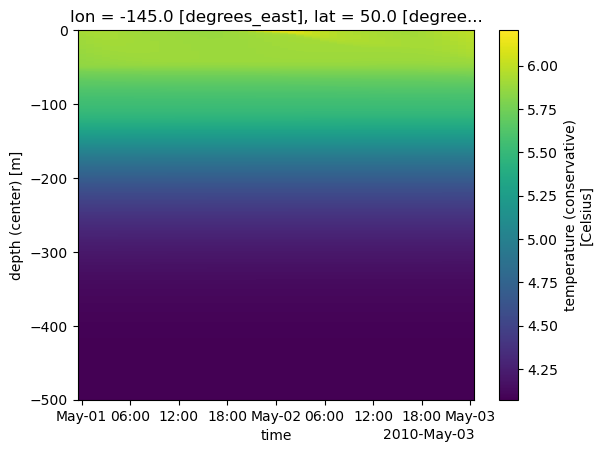

In [45]:
ds.isel(lat=0, lon=0).sel(time=slice(np.datetime64('2010-05-01'), np.datetime64('2010-05-03'))).temp.T.plot()

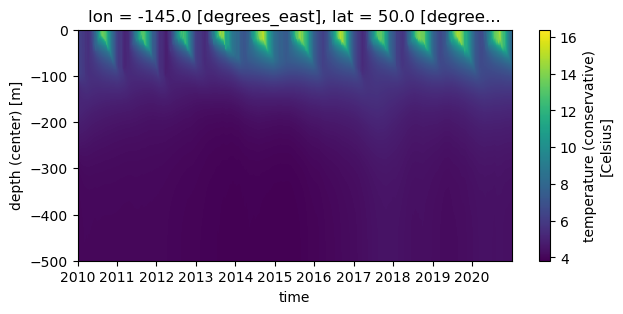

In [6]:
ds.isel(lat=0, lon=0).temp.T.plot(figsize=(7,3))

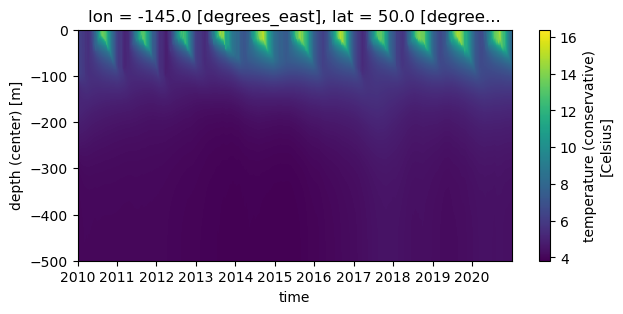

In [ ]:
ds.isel(lat=0, lon=0).temp.T.plot(figsize=(7,3))